# Analiza dialogowa scenariusza: z jakim ładunkiem emocjonalnym?

## Wersja studencka — moduł 3: EMOCJE

W poprzednim module wydobyłeś kwestie dialogowe i zmierzyłeś, *kto* mówi i *ile*. Teraz pytamy o *jak* — z jakim ładunkiem emocjonalnym. Do oceny emocji użyjemy modelu językowego (OpenAI), który przypisze każdej wypowiedzi walencję (od −1 do +1) oraz emocję dyskretną.

Efektem końcowym będą:
1. wczytanie kwestii z `dialogi.csv` i danych o postaciach z `postacie.csv`,
2. konfiguracja połączenia z OpenAI API,
3. batchowa ocena emocji wszystkich kwestii,
4. łuk emocjonalny filmu (walencja wzdłuż scen),
5. wykres rozkładu emocji według płci postaci,
6. zapis pliku `emocje.csv` do dalszej analizy.

## Jak pracować z tym notatnikiem

1. Upewnij się, że masz w tym samym środowisku pliki `dialogi.csv` i `postacie.csv` z NB1.
2. Skopiuj prompt z bieżącego kroku do modelu AI — **ale najpierw przeczytaj go i uzupełnij luki**.
3. Wklej otrzymany kod do pustej komórki pod promptem.
4. Uruchom kod i porównaj z sekcją **Po uruchomieniu powinieneś zobaczyć**.
5. Dopiero po uzyskaniu poprawnego wyniku przejdź dalej.

**Uwaga do kroku z API:** w Etapie 2 będziesz potrzebować klucza do OpenAI API. Klucz jest prywatny — nie wklejaj go na stałe do komórek.

## Twoja kolej: uzupełniaj prompty

W NB1 czytałeś gotowe prompty i uczyłeś się rozumieć ich 7-sekcyjną strukturę. Teraz kilka promptów ma **luki oznaczone `[UZUPEŁNIJ: …]`**, które musisz wypełnić.

**Jak to działa:**
Zamiast tekstu w markdown, prompty żyją teraz w zmiennej `moj_prompt` w komórce kodu.
1. Przeczytaj sekcję **Cel i sens analityczny** — opisuje, *co* chcemy osiągnąć.
2. Przeczytaj sekcję **Po uruchomieniu powinieneś zobaczyć** — mówi, *jak* powinien wyglądać wynik.
3. **Edytuj zmienną `moj_prompt`** — wypełnij każdą lukę `[UZUPEŁNIJ: …]`.
4. **Uruchom komórkę** — asercja sprawdzi, czy wszystkie luki są wypełnione i prompt ma odpowiednią treść.
5. Jeśli asercja przejdzie, skopiuj wypisany prompt do asystenta AI.

Zasada: luka `[UZUPEŁNIJ: …]` opisuje **co** powinieneś tam wpisać — ale Ty decydujesz, **jak** to sformulujesz.

---
## Etap 1/6 — Wczytanie danych wejściowych

Zaczynamy od danych z NB1.

In [1]:
# === ETAP 1/6 · WCZYTANIE DANYCH ===
import os
brak = [f for f in ["dialogi.csv", "postacie.csv"] if not os.path.exists(f)]
if brak:
    raise FileNotFoundError(
        f"⛔ Brakuje plików: {brak}\n"
        "Pobierz je z NB1 (Etap 6) i wgraj do tego środowiska."
    )
print("📍 Etap 1/6 · Wczytanie danych. Pliki dialogi.csv i postacie.csv — znalezione ✓")

📍 Etap 1/6 · Wczytanie danych. Pliki dialogi.csv i postacie.csv — znalezione ✓


### Krok 1A. Wczytanie `dialogi.csv` i `postacie.csv`

#### Cel i sens analityczny

`dialogi.csv` zawiera po jednym wierszu na kwestię. `postacie.csv` zawiera podsumowanie postaci z płcią. Musimy załadować oba i sprawdzić, że wyglądają poprawnie.

#### Prompt dla modelu

```text
Kontekst:
Masz dwa pliki CSV z poprzedniego modułu analizy dialogowej.

Wejście:
Pliki `dialogi.csv` i `postacie.csv` w kodowaniu UTF-8.

Zadanie:
Wczytaj oba pliki do tabel i wyświetl krótki podgląd każdego z nich. Zachowaj wczytane tabele jako zmienne o nazwach `dialogi` i `postacie`.

Pokaż wynik:
- liczbę wierszy i nazwy kolumn każdego pliku,
- pierwsze 5 wierszy z `dialogi`,
- wszystkie wiersze z `postacie` (jest ich mało).

Warunek poprawności:
Kolumny powinny odpowiadać opisanemu formatowi. Jeśli nazwy kolumn są inne, wypisz to wprost.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się wczytać i z jakiego powodu.

Nie rób jeszcze:
Nie oceniaj emocji.
```

In [4]:
import pandas as pd

try:
    # Load the datasets
    dialogi = pd.read_csv('dialogi.csv', encoding='utf-8')
    # Fixing the separator for postacie.csv
    postacie = pd.read_csv('postacie.csv', encoding='utf-8', sep=';')

    # Display info for dialogi
    print(f"Plik 'dialogi.csv': {len(dialogi)} wierszy")
    print(f"Kolumny: {list(dialogi.columns)}")
    display(dialogi.head(5))

    print("\n" + "="*30 + "\n")

    # Display info for postacie
    print(f"Plik 'postacie.csv': {len(postacie)} wierszy")
    print(f"Kolumny: {list(postacie.columns)}")
    display(postacie)

except Exception as e:
    print(f"An error occurred while loading files: {e}")

Plik 'dialogi.csv': 1193 wierszy
Kolumny: ['numer_sceny', 'postac', 'tresc', 'liczba_slow']


,numer_sceny,postac,tresc,liczba_slow
0,1,YOUNG MAN,"No, forget it, it's too risky. I'm through doi...",11
1,1,YOUNG WOMAN,"You always say that, the same thing every time...",15
2,1,YOUNG MAN,I know that's what I always say. I'm always ri...,13
3,1,YOUNG WOMAN,� but you forget about it in a day or two -,12
4,1,YOUNG MAN,"� yeah, well, the days of me forgittin' are ov...",19




Plik 'postacie.csv': 44 wierszy
Kolumny: ['postac', 'liczba_slow', 'liczba_kwestii', 'liczba_scen', 'plec']


,postac,liczba_slow,liczba_kwestii,liczba_scen,plec
0,JULES,3875,209,22,M
1,VINCENT,3467,258,35,M
2,BUTCH,2187,135,15,M
3,MIA,1502,81,16,K
4,THE WOLF,1247,46,8,M
5,LANCE,1048,49,6,M
6,FABIENNE,1041,90,2,K
7,YOUNG MAN,823,27,1,M
8,MAYNARD,740,21,2,M
9,MARSELLUS,614,20,7,M


#### Po uruchomieniu powinieneś zobaczyć

- Liczbę wierszy i kolumny obu plików.
- Kilka pierwszych kwestii z `dialogi`.
- Tabelę postaci z kolumną płeć (K/M/?).

---
## Etap 2/6 — Konfiguracja modelu językowego

Instalujemy bibliotekę OpenAI, podłączamy klucz API i sprawdzamy, czy połączenie działa.

In [3]:
# === ETAP 2/6 · KONFIGURACJA OPENAI ===
assert 'dialogi' in dir(), "⛔ Najpierw uruchom Etap 1 — brak tabeli `dialogi`."
print(f"📍 Etap 2/6 · Konfiguracja OpenAI. Wejście: `dialogi` ({len(dialogi):,} kwestii).")

📍 Etap 2/6 · Konfiguracja OpenAI. Wejście: `dialogi` (1,193 kwestii).


### Krok 2A. Instalacja i klucz API

#### Cel i sens analityczny

Żeby wywołać OpenAI z kodu Pythona, potrzebna jest biblioteka `openai` i klucz API. Klucz wpisujemy przez `getpass` — tak, żeby nie pojawił się w historii komórek.

#### Prompt dla modelu

```text
Kontekst:
Pracujesz w Google Colab i chcesz wywołać OpenAI API z Pythona.

Wejście:
Brak — konfiguracja od zera.

Zadanie:
Zainstaluj pakiet `openai`. Następnie poproś użytkownika o wpisanie klucza API przez `getpass.getpass` i utwórz klienta: `client = openai.OpenAI(api_key=...)`. Na końcu wyślij jedno testowe żądanie do modelu `gpt-4o-mini` (krótka wiadomość: „Hello!") i wydrukuj odpowiedź, żeby potwierdzić że połączenie działa.

Pokaż wynik:
- komunikat, że instalacja się powiodła,
- pole do wpisania klucza (bez jego wyświetlania),
- krótka odpowiedź modelu na testowe zapytanie.

Warunek poprawności:
Model musi odpowiedzieć — nawet jednym zdaniem. Błąd 401 = problem z kluczem.

Jeśli wystąpi błąd:
Wyświetl treść błędu i podpowiedź: sprawdź, czy klucz jest aktywny i ma środki na koncie.

Nie rób jeszcze:
Nie oceniaj kwestii dialogowych.
```

In [5]:
!pip install -q openai

import openai
import getpass

try:
    print("✅ Biblioteka 'openai' została zainstalowana.")
    api_key = getpass.getpass("Wprowadź swój klucza API OpenAI: ")

    client = openai.OpenAI(api_key=api_key)

    # Testowe żądanie
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": "Hello!"}],
        max_tokens=10
    )

    print("\nOdpowiedź testowa modelu:")
    print(response.choices[0].message.content)
    print("\n✅ Połączenie działa poprawnie!")

except Exception as e:
    print(f"\n❌ Wystąpił błąd: {e}")
    if "401" in str(e):
        print("Podpowiedź: Sprawdź, czy Twój klucz API jest aktywny i czy masz dostępne środki na koncie.")

✅ Biblioteka 'openai' została zainstalowana.
Wprowadź swój klucza API OpenAI: ··········

Odpowiedź testowa modelu:
Hello! How can I assist you today?

✅ Połączenie działa poprawnie!


#### Po uruchomieniu powinieneś zobaczyć

- Potwierdzenie instalacji i pole do wpisania klucza API.
- Krótką odpowiedź modelu potwierdzającą działające połączenie.

---
## Etap 3/6 — Ocena emocji dialogów

Model językowy przeanalizuje każdą kwestię i przypisze jej:
- **walencję** — liczbę od −1 (bardzo negatywna) do +1 (bardzo pozytywna),
- **emocję dyskretną** — jedną z sześciu: `radość`, `smutek`, `złość`, `strach`, `zaskoczenie`, `neutralna`.

Wysyłamy kwestie **partiami** — żeby nie przekroczyć limitu żądań per minutę.

In [6]:
# === ETAP 3/6 · OCENA EMOCJI ===
assert 'dialogi' in dir(), "⛔ Najpierw uruchom Etap 1 — brak tabeli `dialogi`."
print(f"📍 Etap 3/6 · Ocena emocji. Wejście: {len(dialogi):,} kwestii do oceny.")

📍 Etap 3/6 · Ocena emocji. Wejście: 1,193 kwestii do oceny.


### Krok 3A. Batchowa ocena emocji

#### Cel i sens analityczny

Ocena linia po linii (jedno żądanie = jedna kwestia) jest wolna i kosztowna. Batching — przesyłanie wielu kwestii w jednym żądaniu i odebranie odpowiedzi jako tablicy JSON — jest znacznie wydajniejszy.

#### Twoja kolej: uzupełnij i uruchom

> **Instrukcja dla modelu (środkowy blok między `---`) jest wbudowana na stałe — nie zmieniaj jej. Wypełnij dwie oznaczone luki `[UZUPEŁNIJ: …]`, potem uruchom.**

In [7]:
# TWOJA KOLEJ: wypełnij każdą lukę, potem uruchom tę komórkę.
moj_prompt = """
Kontekst:
Masz tabelę kwestii dialogowych w zmiennej `dialogi`. Masz skonfigurowanego klienta OpenAI API (zmienna `client` — obiekt `openai.OpenAI`).

Wejście:
Tabela `dialogi` z kolumnami: numer sceny, postać, treść kwestii.

Zadanie:
Napisz funkcję przetwarzającą kwestie partiami po 20. Dla każdej partii wyślij do OpenAI jedno żądanie (`client.chat.completions.create`, model `gpt-4o-mini`) z poniższą instrukcją wbudowaną na stałe w kod:

---
Oceń emocje poniższych kwestii dialogowych ze scenariusza filmowego.
Dla każdej kwestii zwróć obiekt JSON z polami:
- "id": numer porządkowy kwestii w tej partii (0-indeksowany),
- "walencja": liczba od -1.0 (bardzo negatywna) do 1.0 (bardzo pozytywna),
- "emocja": jedna z: radość, smutek, złość, strach, zaskoczenie, neutralna.
Zwróć WYŁĄCZNIE tablicę JSON, bez żadnego dodatkowego tekstu ani formatowania markdown.
Kwestie do oceny:
[TUTAJ WSTAW KWESTIE W FORMACIE: "id | postać: treść kwestii"]
---

Po odebraniu odpowiedzi sparsuj JSON i dołącz wyniki do tabeli kwestii jako nowe kolumny `walencja` i `emocja`. Zachowaj wynik jako zmienną o nazwie `emocje`. Jeśli parsowanie partii się nie powiedzie, wypełnij brakujące wiersze: walencja=0, emocja="neutralna" i wypisz ostrzeżenie. Dodaj opóźnienie 2 sekundy między partiami.

Pokaż wynik:
- komunikaty o przetwarzaniu kolejnych partii (numer partii i postęp),
- po zakończeniu: łączną liczbę ocenionych kwestii,
- próbkę 10 wierszy: postać | treść (pierwsze 60 znaków) | walencja | emocja.

Warunek poprawności:
Liczba ocenionych kwestii = liczba wierszy w `dialogi`. Kolumna `emocja` zawiera wyłącznie wartości z listy: radość, smutek, złość, strach, zaskoczenie, neutralna.

Jeśli wystąpi błąd:
Wypisz, przy której partii wystąpił problem i pokaż surową odpowiedź modelu.

Nie rób jeszcze:
Nie rysuj wykresów.
"""
assert "[UZUPEŁNIJ" not in moj_prompt, \
    "⛔ Zostały nieuzupełnione luki [UZUPEŁNIJ… — wypełnij każdą."
assert len(moj_prompt.strip()) > 200, \
    "⛔ Prompt za krótki — wypełnij sekcje konkretną treścią o SWOIM filmie."
assert "emocje" in moj_prompt, \
    "⛔ Upewnij się, że Twój prompt mówi modelowi o zapisaniu wyniku w zmiennej `emocje`."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę kwestii dialogowych w zmiennej `dialogi`. Masz skonfigurowanego klienta OpenAI API (zmienna `client` — obiekt `openai.OpenAI`).

Wejście:
Tabela `dialogi` z kolumnami: numer sceny, postać, treść kwestii.

Zadanie:
Napisz funkcję przetwarzającą kwestie partiami po 20. Dla każdej partii wyślij do OpenAI jedno żądanie (`client.chat.completions.create`, model `gpt-4o-mini`) z poniższą instrukcją wbudowaną na stałe w kod:

---
Oceń emocje poniższych kwestii dialogowych ze scenariusza filmowego.
Dla każdej kwestii zwróć obiekt JSON z polami:
- "id": numer porządkowy kwestii w tej partii (0-indeksowany),
- "walencja": liczba od -1.0 (bardzo negatywna) do 1.0 (bardzo pozytywna),
- "emocja": jedna z: radość, smutek, złość, strach, zaskoczenie, neutralna.
Zwróć WYŁĄCZNIE tablicę JSON, bez żadnego dodatkowego tekstu ani formatowania markdown.
Kwestie do oceny:
[TUTAJ WSTAW KWESTIE W FORMACIE: "id | postać: treść kwes

In [8]:
import json
import time
import pandas as pd

def analyze_emotions_in_batches(df, batch_size=20, delay=2):
    emocje = df.copy()
    emocje['walencja'] = 0.0
    emocje['emocja'] = 'neutralna'

    total_lines = len(df)

    for i in range(0, total_lines, batch_size):
        batch = df.iloc[i : i + batch_size]
        lines_to_eval = []
        for idx, row in batch.iterrows():
            local_id = idx - i
            lines_to_eval.append(f"{local_id} | {row['postac']}: {row['tresc']}")

        content = "\n".join(lines_to_eval)
        prompt = f"""Oceń emocje poniższych kwestii dialogowych ze scenariusza filmowego.
Dla każdej kwestii zwróć obiekt JSON z polami:
- \"id\": numer porządkowy kwestii w tej partii (0-indeksowany),
- \"walencja\": liczba od -1.0 (bardzo negatywna) do 1.0 (bardzo pozytywna),
- \"emocja\": jedna z: radość, smutek, złość, strach, zaskoczenie, neutralna.
Zwróć WYŁĄCZNIE tablicę JSON, bez żadnego dodatkowego tekstu ani formatowania markdown.
Kwestie do oceny:
{content}"""

        print(f"Przetwarzanie partii {i//batch_size + 1}... (Postęp: {min(i + batch_size, total_lines)}/{total_lines})")

        raw_output = ""
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt}],
                temperature=0
            )

            raw_output = response.choices[0].message.content.strip()
            # Handle potential markdown wrapping
            if raw_output.startswith("```"):
                raw_output = raw_output.strip("```").replace("json", "", 1).strip()

            results = json.loads(raw_output)

            for res in results:
                real_idx = i + res['id']
                if real_idx < total_lines:
                    emocje.at[real_idx, 'walencja'] = float(res.get('walencja', 0.0))
                    emocje.at[real_idx, 'emocja'] = res.get('emocja', 'neutralna')

        except Exception as e:
            print(f"⚠️ Problem przy partii {i//batch_size + 1}: {e}")
            print(f"Surowa odpowiedź modelu: {raw_output[:200]}...")

        time.sleep(delay)

    return emocje

# Uruchomienie analizy
emocje = analyze_emotions_in_batches(dialogi)

print(f"\nZakończono! Łączna liczba ocenionych kwestii: {len(emocje)}")
print("Próbka wyników:")
display(emocje[['postac', 'tresc', 'walencja', 'emocja']].head(10).assign(tresc=lambda x: x['tresc'].str[:60] + '...'))

Przetwarzanie partii 1... (Postęp: 20/1193)
Przetwarzanie partii 2... (Postęp: 40/1193)
Przetwarzanie partii 3... (Postęp: 60/1193)
Przetwarzanie partii 4... (Postęp: 80/1193)
Przetwarzanie partii 5... (Postęp: 100/1193)
Przetwarzanie partii 6... (Postęp: 120/1193)
Przetwarzanie partii 7... (Postęp: 140/1193)
Przetwarzanie partii 8... (Postęp: 160/1193)
Przetwarzanie partii 9... (Postęp: 180/1193)
Przetwarzanie partii 10... (Postęp: 200/1193)
Przetwarzanie partii 11... (Postęp: 220/1193)
Przetwarzanie partii 12... (Postęp: 240/1193)
Przetwarzanie partii 13... (Postęp: 260/1193)
Przetwarzanie partii 14... (Postęp: 280/1193)
Przetwarzanie partii 15... (Postęp: 300/1193)
Przetwarzanie partii 16... (Postęp: 320/1193)
Przetwarzanie partii 17... (Postęp: 340/1193)
Przetwarzanie partii 18... (Postęp: 360/1193)
Przetwarzanie partii 19... (Postęp: 380/1193)
Przetwarzanie partii 20... (Postęp: 400/1193)
Przetwarzanie partii 21... (Postęp: 420/1193)
Przetwarzanie partii 22... (Postęp: 440/1193)
P

,postac,tresc,walencja,emocja
0,YOUNG MAN,"No, forget it, it's too risky. I'm through doi...",-0.7,złość
1,YOUNG WOMAN,"You always say that, the same thing every time...",-0.5,smutek
2,YOUNG MAN,I know that's what I always say. I'm always ri...,-0.3,neutralna
3,YOUNG WOMAN,� but you forget about it in a day or two -...,-0.4,smutek
4,YOUNG MAN,"� yeah, well, the days of me forgittin' are ov...",0.2,radość
5,YOUNG WOMAN,"When you go on like this, you know what you so...",-0.2,neutralna
6,YOUNG MAN,"I sound like a sensible fucking man, is what I...",0.3,radość
7,YOUNG WOMAN,You sound like a duck. (imitates a duck) Quack...,0.5,radość
8,YOUNG MAN,"Well take heart, 'cause you're never gonna haf...",0.4,radość
9,YOUNG WOMAN,"After tonight. The boy and girl laugh, their l...",0.6,radość


#### Po uruchomieniu powinieneś zobaczyć

- Komunikaty o przetwarzaniu kolejnych partii.
- Próbkę kwestii z przypisanymi walencjami i emocjami.

> **Wskazówka:** jeśli model zwraca JSON opakowany w znaczniki ` ```json ... ``` `, poproś go o poprawkę: *„usuń markdown z odpowiedzi — zwracaj tylko czystą tablicę JSON"*.

### Krok 3B. Podgląd i kontrola jakości

#### Cel i sens analityczny

Zanim narysujemy wykresy, sprawdzamy, czy rozkład emocji wygląda sensownie — czy model nie wpadł w schemat (np. wszystko „neutralna").

#### Twoja kolej: uzupełnij i uruchom

Przejrzyj dane w komórce podglądu powyżej. Wypełnij jedną lukę `[UZUPEŁNIJ: …]` w komórce kodu poniżej i uruchom ją — komórka sprawdzi i wypisze gotowy prompt.

In [10]:
# TWOJA KOLEJ: wypełnij lukę [UZUPEŁNIJ: …], potem uruchom tę komórkę.
moj_prompt = """
Kontekst:
Masz tabelę kwestii z przypisanymi emocjami i walencjami w zmiennej `emocje`.

Wejście:
Tabela `emocje` z kolumnami widocznymi powyżej w komórce podglądu.

Zadanie:
Policz rozkład emocji: ile kwestii i jaki procent przypada na każdą kategorię. Pokaż statystyki opisowe walencji (min, mediana, średnia, max). Wypisz 3 kwestie z najwyższą walencją i 3 z najniższą (postać + treść + walencja).

Pokaż wynik:
- tabelę: emocja | liczba kwestii | procent,
- statystyki walencji (min, mediana, max),
- 3 kwestie najwyżej i 3 najniżej nacechowane emocjonalnie.

Warunek poprawności:
Jeśli jedna emocja ma ponad 90% kwestii, wypisz ostrzeżenie

Jeśli wystąpi błąd:
Wyjaśnij, czy kolumna emocja jest pusta albo zawiera nieoczekiwane wartości.

Nie rób jeszcze:
Nie rysuj wykresów.
"""
assert "[UZUPEŁNIJ" not in moj_prompt, \
    "⛔ Wypełnij lukę [UZUPEŁNIJ: …] — podaj próg procentowy dla zdegenerowanego rozkładu."
assert len(moj_prompt.strip()) > 200, \
    "⛔ Prompt za krótki — wypełnij brakującą sekcję."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę kwestii z przypisanymi emocjami i walencjami w zmiennej `emocje`.

Wejście:
Tabela `emocje` z kolumnami widocznymi powyżej w komórce podglądu.

Zadanie:
Policz rozkład emocji: ile kwestii i jaki procent przypada na każdą kategorię. Pokaż statystyki opisowe walencji (min, mediana, średnia, max). Wypisz 3 kwestie z najwyższą walencją i 3 z najniższą (postać + treść + walencja).

Pokaż wynik:
- tabelę: emocja | liczba kwestii | procent,
- statystyki walencji (min, mediana, max),
- 3 kwestie najwyżej i 3 najniżej nacechowane emocjonalnie.

Warunek poprawności:
Jeśli jedna emocja ma ponad 90% kwestii, wypisz ostrzeżenie

Jeśli wystąpi błąd:
Wyjaśnij, czy kolumna emocja jest pusta albo zawiera nieoczekiwane wartości.

Nie rób jeszcze:
Nie rysuj wykresów.



In [11]:
import pandas as pd

try:
    # 1. Rozkład emocji
    counts = emocje['emocja'].value_counts()
    percents = emocje['emocja'].value_counts(normalize=True) * 100
    distribution_df = pd.DataFrame({'liczba kwestii': counts, 'procent': percents})

    print("=== ROZKŁAD EMOCJI ===")
    display(distribution_df)

    # Warunek poprawności
    if (percents > 90).any():
        dominant = percents.idxmax()
        print(f"\n⚠️ OSTRZEŻENIE: Rozkład jest zdegenerowany! Emocja '{dominant}' stanowi {percents.max():.2f}% wszystkich kwestii.\n")

    # 2. Statystyki walencji
    print("=== STATYSTYKI WALENCJI ===")
    v_stats = emocje['walencja'].agg(['min', 'median', 'mean', 'max'])
    print(v_stats.to_string())

    # 3. Kwestie skrajne
    print("\n=== 3 NAJWYŻSZE WALENCJE ===")
    display(emocje.nlargest(3, 'walencja')[['postac', 'tresc', 'walencja']])

    print("\n=== 3 NAJNIŻSZE WALENCJE ===")
    display(emocje.nsmallest(3, 'walencja')[['postac', 'tresc', 'walencja']])

except Exception as e:
    if 'emocja' not in emocje.columns or emocje['emocja'].isnull().all():
        print("❌ Błąd: Kolumna 'emocja' jest pusta lub nie istnieje.")
    else:
        print(f"❌ Wystąpił błąd podczas analizy: {e}")

=== ROZKŁAD EMOCJI ===


,liczba kwestii,procent
emocja,,
neutralna,509,42.665549
radość,313,26.236379
złość,172,14.417435
strach,109,9.136630
smutek,71,5.951383
zaskoczenie,19,1.592624


=== STATYSTYKI WALENCJI ===
min      -1.00000
median    0.00000
mean     -0.03378
max       1.00000

=== 3 NAJWYŻSZE WALENCJE ===


,postac,tresc,walencja
352,MIA,Yummy!,1.0
358,VINCENT,Goddamn! That's a pretty fuckin' good milk shake.,1.0
359,MIA,Told ya.,1.0



=== 3 NAJNIŻSZE WALENCJE ===


,postac,tresc,walencja
112,JULES,Sent a couple of guys over to his place. They...,-1.0
137,JULES,"Look, just because I wouldn't give no man a fo...",-1.0
196,BRETT,I just want you to know how sorry we are about...,-1.0


#### Po uruchomieniu powinieneś zobaczyć

- Tabelę: emocja | liczba kwestii | procent.
- Podstawowe statystyki walencji (min, mediana, max).
- 3 kwestie z najwyższą walencją i 3 z najniższą.

> **Jeśli rozkład jest zdegenerowany** (np. 90% „neutralna") — wróć do Kroku 3A i poproś model AI o zmodyfikowanie wbudowanej instrukcji oceny emocji, żeby była bardziej rozróżniająca.

---
## Etap 4/6 — Łuk emocjonalny filmu

Teraz patrzymy na emocje w czasie — jak zmienia się nastrój od pierwszej do ostatniej sceny. To tzw. *emotional arc*, znany z badań Reagana i in. (2016) oraz Vonneguta.

In [12]:
# === ETAP 4/6 · ŁUK EMOCJONALNY ===
assert 'emocje' in dir(), "⛔ Najpierw uruchom Etap 3 — brak tabeli `emocje`."
print(f"📍 Etap 4/6 · Łuk emocjonalny. Wejście: `emocje` ({len(emocje):,} kwestii z walencją).")

📍 Etap 4/6 · Łuk emocjonalny. Wejście: `emocje` (1,193 kwestii z walencją).


In [13]:
# HIPOTEZA — wpisz ZANIM narysujesz wykres
# Gdzie w Twoim filmie będzie najgłębsza dolina emocjonalna (najbardziej mroczna sekwencja)?
# Opisz scenę lub moment fabuły.
moja_hipoteza_4 = "środkowa"   # np. "środkowa część — scena konfrontacji głównych bohaterów"
assert moja_hipoteza_4.strip(), \
    "⛔ Najpierw opisz, gdzie spodziewasz się emocjonalnego dołka — zanim zobaczysz wykres."
print("✏️  Hipoteza zapisana. Teraz wygeneruj wykres łuku emocjonalnego.")

✏️  Hipoteza zapisana. Teraz wygeneruj wykres łuku emocjonalnego.


#### Twoja kolej: uzupełnij i uruchom

Przejrzyj dane w komórce podglądu powyżej. Wypełnij jedną lukę `[UZUPEŁNIJ: …]` w komórce kodu poniżej i uruchom.

In [14]:
# TWOJA KOLEJ: wypełnij lukę [UZUPEŁNIJ: …], potem uruchom tę komórkę.
moj_prompt = """
Kontekst:
Masz tabelę kwestii z walencją i numerem sceny w zmiennej `emocje`.

Wejście:
Tabela `emocje` z kolumnami widocznymi powyżej w komórce podglądu. Potrzebujesz kolumny z numerem sceny i kolumny walencja.

Zadanie:
(1) Wylicz średnią walencję dla każdej sceny. (2) Wygładź wynik oknem przesuwnym o szerokości 5 scen. (3) Narysuj wykres liniowy: oś X = numer sceny, oś Y = wygładzona walencja, pozioma linia zerowa wyróżniona kolorem.

Pokaż wynik:
- wykres liniowy z tytułem i etykietami osi,
- wyraźna pozioma linia y=0 (inna grubość lub kolor),
- numer sceny z najniższą wygładzoną walencją wypisany pod wykresem.

Warunek poprawności:
Wykres nie powinien być płaski — wypisz ostrzeżenie, jeśli odchylenie standardowe wygładzonej walencji jest mniejsze niż 0.05.

Jeśli wystąpi błąd:
Wyjaśnij, czy tabela nie ma kolumny walencja albo czy wszystkie numery scen są identyczne.

Nie rób jeszcze:
Nie rysuj wykresu emocja × płeć.
"""
assert "[UZUPEŁNIJ" not in moj_prompt, \
    "⛔ Wypełnij lukę [UZUPEŁNIJ: …] — podaj szerokość okna wygładzającego (liczbę scen)."
assert len(moj_prompt.strip()) > 200, \
    "⛔ Prompt za krótki — wypełnij brakującą sekcję."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę kwestii z walencją i numerem sceny w zmiennej `emocje`.

Wejście:
Tabela `emocje` z kolumnami widocznymi powyżej w komórce podglądu. Potrzebujesz kolumny z numerem sceny i kolumny walencja.

Zadanie:
(1) Wylicz średnią walencję dla każdej sceny. (2) Wygładź wynik oknem przesuwnym o szerokości 5 scen. (3) Narysuj wykres liniowy: oś X = numer sceny, oś Y = wygładzona walencja, pozioma linia zerowa wyróżniona kolorem.

Pokaż wynik:
- wykres liniowy z tytułem i etykietami osi,
- wyraźna pozioma linia y=0 (inna grubość lub kolor),
- numer sceny z najniższą wygładzoną walencją wypisany pod wykresem.

Warunek poprawności:
Wykres nie powinien być płaski — wypisz ostrzeżenie, jeśli odchylenie standardowe wygładzonej walencji jest mniejsze niż 0.05.

Jeśli wystąpi błąd:
Wyjaśnij, czy tabela nie ma kolumny walencja albo czy wszystkie numery scen są identyczne.

Nie rób jeszcze:
Nie rysuj wykresu emocja × płeć.



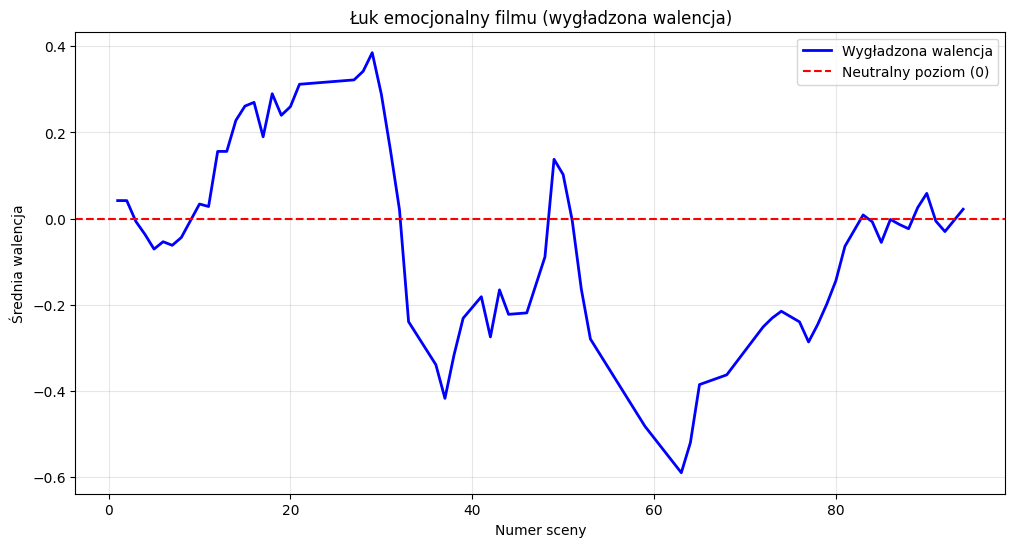

Scena z najniższą wygładzoną walencją: 63 (wartość: -0.590)


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

try:
    # 1. Średnia walencja dla każdej sceny
    scene_valence = emocje.groupby('numer_sceny')['walencja'].mean().reset_index()

    # 2. Wygładzanie oknem przesuwnym (szerokość 5)
    scene_valence['wygładzona_walencja'] = scene_valence['walencja'].rolling(window=5, center=True, min_periods=1).mean()

    # 3. Rysowanie wykresu
    plt.figure(figsize=(12, 6))
    plt.plot(scene_valence['numer_sceny'], scene_valence['wygładzona_walencja'], color='blue', linewidth=2, label='Wygładzona walencja')

    # Linia zerowa
    plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Neutralny poziom (0)')

    plt.title('Łuk emocjonalny filmu (wygładzona walencja)')
    plt.xlabel('Numer sceny')
    plt.ylabel('Średnia walencja')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Wynik: scena z najniższą walencją
    min_row = scene_valence.loc[scene_valence['wygładzona_walencja'].idxmin()]
    print(f"Scena z najniższą wygładzoną walencją: {int(min_row['numer_sceny'])} (wartość: {min_row['wygładzona_walencja']:.3f})")

    # Warunek poprawności
    std_dev = scene_valence['wygładzona_walencja'].std()
    if std_dev < 0.05:
        print(f"\n⚠️ OSTRZEŻENIE: Wykres może być zbyt płaski! Odchylenie standardowe wynosi tylko {std_dev:.4f}.")

except Exception as e:
    if 'walencja' not in emocje.columns:
        print("❌ Błąd: Tabela 'emocje' nie posiada kolumny 'walencja'.")
    elif emocje['numer_sceny'].nunique() <= 1:
        print("❌ Błąd: Wszystkie numery scen są identyczne lub brakuje zróżnicowania scen.")
    else:
        print(f"❌ Wystąpił błąd: {e}")

In [17]:
# CHECKPOINT — uzupełnij na podstawie wykresu powyżej
numer_doliny = "62"  # np. "45" — numer sceny z najgłębszą doliną (odczytaj z wykresu)
assert numer_doliny.strip().isdigit(), \
    "⛔ Wpisz numer sceny z najniższą walencją (odczytaj z wykresu)."
print(f"📊 Checkpoint: najgłębsza dolina emocjonalna — scena {numer_doliny}.")
print(f"Twoja hipoteza mówiła o: '{moja_hipoteza_4[:80]}'")
print("Porównaj z hipotezą powyżej.")

📊 Checkpoint: najgłębsza dolina emocjonalna — scena 62.
Twoja hipoteza mówiła o: 'środkowa'
Porównaj z hipotezą powyżej.


#### Pytanie interpretacyjne

Gdzie na wykresie są doliny i szczyty? Czy pokrywają się z ważnymi zwrotami fabuły, które pamiętasz z filmu? Vonnegut opisywał opowieści jako „kształty" — jaki kształt ma Twój film?

### Krok 4B. Rozkład emocji dyskretnych w czasie

#### Cel i sens analityczny

Walencja pyta *czy* scena jest nacechowana pozytywnie lub negatywnie. Emocje dyskretne mówią *jak* — złość i smutek to obie emocje negatywne, ale niosą inne znaczenie narracyjne. Ten wykres pokazuje, jak zmienia się proporcja poszczególnych emocji wzdłuż scenariusza.

In [18]:
# PRZEGLĄD — uruchom przed uzupełnieniem prompta
assert 'emocje' in dir(), "⛔ Najpierw uruchom Etap 3."
_scene_col = next((c for c in emocje.columns
                   if any(k in c.lower() for k in ('scena', 'scene', 'numer', 'num'))), None)
if _scene_col:
    _n = emocje[_scene_col].nunique()
    print(f"📋 Liczba scen: {_n}")
    print(f"    → Grupowanie co  5 scen → ~{_n // 5:>2} słupków")
    print(f"    → Grupowanie co 10 scen → ~{_n // 10:>2} słupków")
    print(f"    → Grupowanie co 15 scen → ~{_n // 15:>2} słupków")
else:
    print(f"Kolumny dostępne: {list(emocje.columns)}")
_emocja_col = next((c for c in emocje.columns if 'emocj' in c.lower()), None)
if _emocja_col:
    print(f"\nEmocje w zbiorze: {list(emocje[_emocja_col].unique())}")

📋 Liczba scen: 67
    → Grupowanie co  5 scen → ~13 słupków
    → Grupowanie co 10 scen → ~ 6 słupków
    → Grupowanie co 15 scen → ~ 4 słupków

Emocje w zbiorze: ['złość', 'smutek', 'neutralna', 'radość', 'strach', 'zaskoczenie']


#### Wypełnij jedną lukę

Prompt jest prawie gotowy. Znajdź `[UZUPEŁNIJ: …]` i wpisz, co ile scen grupować dane — to decyzja o rozdzielczości wykresu (patrz podgląd powyżej).

In [19]:
# TWOJA KOLEJ: uzupełnij jedną lukę [UZUPEŁNIJ: …], potem uruchom.
moj_prompt = """
Kontekst:
Masz tabelę kwestii z przypisanymi emocjami dyskretycznymi i numerami scen w zmiennej `emocje`. Kolumna emocja zawiera 6 kategorii: radość/smutek/złość/strach/zaskoczenie/neutralna.

Wejście:
Tabela `emocje` — sprawdź jej kolumny poleceniem `emocje.columns` i dopasuj nazwy.

Zadanie:
(1) Pogrupuj sceny w przedziały po 15 scen. (2) Dla każdego przedziału policz, jaki procent kwestii przypada na każdą z 6 emocji. (3) Narysuj skumulowany wykres słupkowy (stacked bar): oś X = przedział scen, oś Y = procent (0–100%), każda emocja = inny kolor. (4) Dodaj tytuł „Rozkład emocji w czasie" i legendę z nazwami emocji.

Pokaż wynik:
- skumulowany wykres słupkowy z tytułem i etykietami osi,
- legenda 6 emocji z kolorami.

Warunek poprawności:
Dla każdego słupka suma procentów = 100%. Każda emocja ma unikalny kolor.

Jeśli wystąpi błąd:
Sprawdź dostępne wartości emocji: `emocje['nazwa_kolumny'].unique()`.

Nie rób jeszcze:
Nie analizuj emocji per postać.
"""
assert "[UZUPEŁNIJ" not in moj_prompt, \
    "⛔ Pozostała luka [UZUPEŁNIJ: …] — wpisz, co ile scen grupujesz dane."
assert "emocje" in moj_prompt, \
    "⛔ Prompt musi odwoływać się do zmiennej `emocje`."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę kwestii z przypisanymi emocjami dyskretycznymi i numerami scen w zmiennej `emocje`. Kolumna emocja zawiera 6 kategorii: radość/smutek/złość/strach/zaskoczenie/neutralna.

Wejście:
Tabela `emocje` — sprawdź jej kolumny poleceniem `emocje.columns` i dopasuj nazwy.

Zadanie:
(1) Pogrupuj sceny w przedziały po 15 scen. (2) Dla każdego przedziału policz, jaki procent kwestii przypada na każdą z 6 emocji. (3) Narysuj skumulowany wykres słupkowy (stacked bar): oś X = przedział scen, oś Y = procent (0–100%), każda emocja = inny kolor. (4) Dodaj tytuł „Rozkład emocji w czasie" i legendę z nazwami emocji.

Pokaż wynik:
- skumulowany wykres słupkowy z tytułem i etykietami osi,
- legenda 6 emocji z kolorami.

Warunek poprawności:
Dla każdego słupka suma procentów = 100%. Każda emocja ma unikalny kolor.

Jeśli wystąpi błąd:
Sprawdź dostępne wartości emocji: `emocje['nazwa_kolumny'].unique()`.

Nie rób jeszcze:
Nie anal

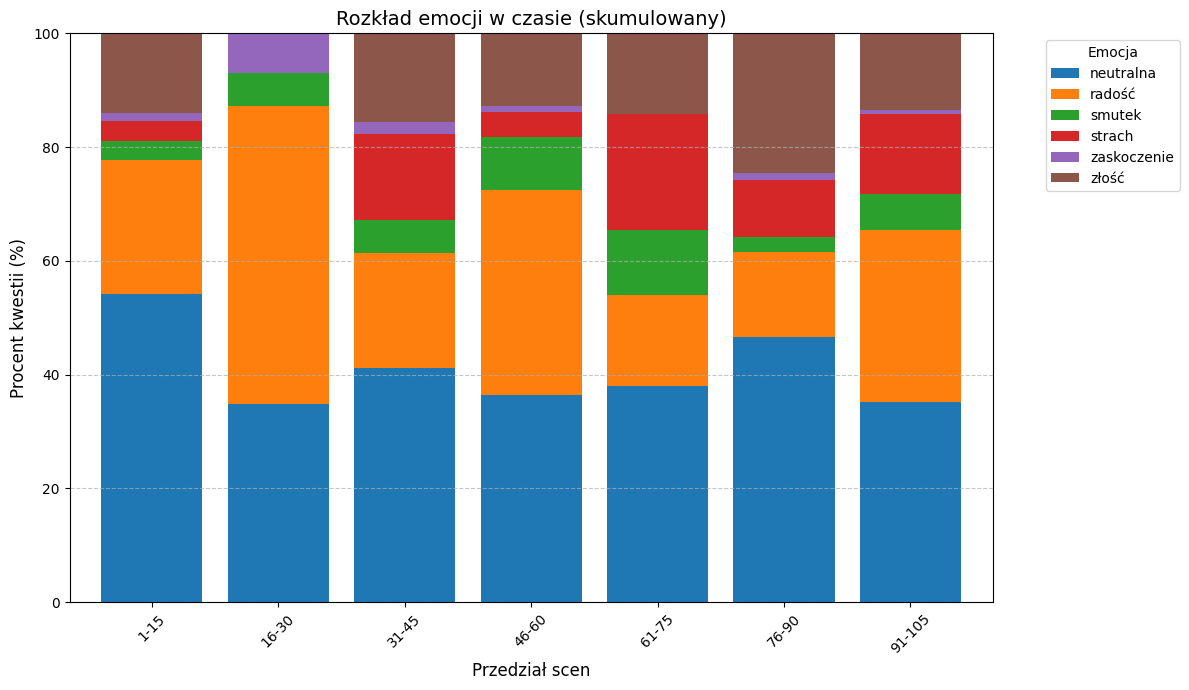

Weryfikacja: Suma procentów dla każdego słupka:
przedzial_scen
1-15      100.0
16-30     100.0
31-45     100.0
46-60     100.0
61-75     100.0
76-90     100.0
91-105    100.0
dtype: float64


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. Przygotowanie przedziałów scen (co 15)
    bin_size = 15
    bins = range(0, emocje['numer_sceny'].max() + bin_size, bin_size)
    labels = [f"{i+1}-{i+bin_size}" for i in bins[:-1]]

    # Dodanie kolumny z przedziałem do tabeli
    emocje['przedzial_scen'] = pd.cut(emocje['numer_sceny'], bins=bins, labels=labels, include_lowest=True)

    # 2. Obliczanie procentowego rozkładu emocji w przedziałach
    # Grupowanie i liczenie wystąpień
    counts = emocje.groupby(['przedzial_scen', 'emocja'], observed=False).size().unstack(fill_value=0)

    # Normalizacja do procentów (suma wiersza = 100%)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100

    # 3. Rysowanie skumulowanego wykresu słupkowego
    ax = percentages.plot(kind='bar', stacked=True, figsize=(12, 7), width=0.8)

    plt.title('Rozkład emocji w czasie (skumulowany)', fontsize=14)
    plt.xlabel('Przedział scen', fontsize=12)
    plt.ylabel('Procent kwestii (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.legend(title='Emocja', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Dodanie siatki pomocniczej dla osi Y
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Weryfikacja sumy
    print("Weryfikacja: Suma procentów dla każdego słupka:")
    print(percentages.sum(axis=1).round(2))

except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")
    print(f"Dostępne kolumny: {list(emocje.columns)}")
    if 'emocja' in emocje.columns:
        print(f"Wartości emocji: {emocje['emocja'].unique()}")

#### Po uruchomieniu powinieneś zobaczyć

- Skumulowany wykres słupkowy z 6 emocjami w różnych kolorach.
- Widoczne zmiany proporcji emocji między różnymi częściami scenariusza.

> **Pytanie interpretacyjne:** Czy emocja dominująca zmienia się między początkiem a końcem? W którym fragmencie pojawia się najwięcej złości? Kiedy najwięcej strachu?

### Krok 4C. Łuk emocjonalny wybranych postaci

#### Cel i sens analityczny

Ta sama scena, różne postacie — różne emocje. Antagonista może przeżywać radość dokładnie tam, gdzie protagonista przeżywa strach. Ten wykres zestawia trajektorie walencji trzech wybranych postaci wzdłuż całego scenariusza.

In [21]:
# PRZEGLĄD — uruchom przed uzupełnieniem prompta, żeby wybrać 3 postacie
assert 'emocje' in dir(), "⛔ Najpierw uruchom Etap 3."
_char_col = next((c for c in emocje.columns
                  if any(k in c.lower() for k in ('postać', 'postac', 'character', 'speaker', 'bohater'))), None)
if _char_col:
    print(f"📋 Postaci z największą liczbą kwestii (kolumna: '{_char_col}'):\n")
    print(emocje.groupby(_char_col).size().sort_values(ascending=False).head(15).to_string())
    print("\n→ Wybierz 3 postacie i wpisz ich nazwy DOKŁADNIE jak powyżej.")
else:
    print(f"Kolumny dostępne: {list(emocje.columns)}")
    print("Sprawdź, która kolumna zawiera nazwy postaci.")

📋 Postaci z największą liczbą kwestii (kolumna: 'postac'):

postac
VINCENT        258
JULES          209
BUTCH          135
FABIENNE        90
MIA             81
LANCE           49
THE WOLF        46
PUMPKIN         34
BRETT           27
YOUNG MAN       27
JIMMIE          26
YOUNG WOMAN     24
MAYNARD         21
JODY            21
MARSELLUS       20

→ Wybierz 3 postacie i wpisz ich nazwy DOKŁADNIE jak powyżej.


#### Wypełnij jedną lukę

Prompt jest prawie gotowy. Znajdź `[UZUPEŁNIJ: …]` i wpisz nazwy trzech postaci — **dokładnie tak**, jak figurują w danych powyżej (wielkie litery, spacje, pisownia).

In [22]:
# TWOJA KOLEJ: uzupełnij jedną lukę [UZUPEŁNIJ: …], potem uruchom.
moj_prompt = """
Kontekst:
Masz tabelę kwestii z walencją (-1 do +1) i numerami scen w zmiennej `emocje`. Kolumny widoczne powyżej w komórce podglądu.

Wejście:
Tabela `emocje`. Trzy postacie do porównania: "VINCENT, JULES, BUTCH".

Zadanie:
(1) Dla każdej z trzech postaci wybierz wiersze z `emocje`. (2) Oblicz średnią walencję na scenę dla każdej postaci. (3) Narysuj wykres liniowy z trzema liniami — jedna linia na postać, oś X = numer sceny, oś Y = walencja od -1 do +1. (4) Dodaj poziomą linię zerową (y=0). (5) Dodaj legendę z imionami postaci i tytuł „Łuk emocjonalny wybranych postaci".

Pokaż wynik:
- wykres liniowy z 3 liniami w różnych kolorach,
- legenda z imionami postaci,
- dla każdej postaci: liczba scen, w których wystąpiła (pod wykresem).

Warunek poprawności:
Na wykresie widać co najmniej 2 z 3 postaci. Jeśli postać ma mniej niż 5 scen, wypisz ostrzeżenie zamiast przerywać z błędem.

Jeśli wystąpi błąd:
Sprawdź dokładną pisownię imion: `emocje['kolumna_postaci'].unique()`.

Nie rób jeszcze:
Nie zapisuj pliku.
"""
assert "[UZUPEŁNIJ" not in moj_prompt, \
    "⛔ Pozostała luka [UZUPEŁNIJ: …] — wpisz nazwy 3 postaci oddzielone przecinkami."
assert "emocje" in moj_prompt, \
    "⛔ Prompt musi odwoływać się do zmiennej `emocje`."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę kwestii z walencją (-1 do +1) i numerami scen w zmiennej `emocje`. Kolumny widoczne powyżej w komórce podglądu.

Wejście:
Tabela `emocje`. Trzy postacie do porównania: "VINCENT, JULES, BUTCH".

Zadanie:
(1) Dla każdej z trzech postaci wybierz wiersze z `emocje`. (2) Oblicz średnią walencję na scenę dla każdej postaci. (3) Narysuj wykres liniowy z trzema liniami — jedna linia na postać, oś X = numer sceny, oś Y = walencja od -1 do +1. (4) Dodaj poziomą linię zerową (y=0). (5) Dodaj legendę z imionami postaci i tytuł „Łuk emocjonalny wybranych postaci".

Pokaż wynik:
- wykres liniowy z 3 liniami w różnych kolorach,
- legenda z imionami postaci,
- dla każdej postaci: liczba scen, w których wystąpiła (pod wykresem).

Warunek poprawności:
Na wykresie widać co najmniej 2 z 3 postaci. Jeśli postać ma mniej niż 5 scen, wypisz ostrzeżenie zamiast przerywać z błędem.

Jeśli wystąpi błąd:
Sprawdź dokładną pisownię im

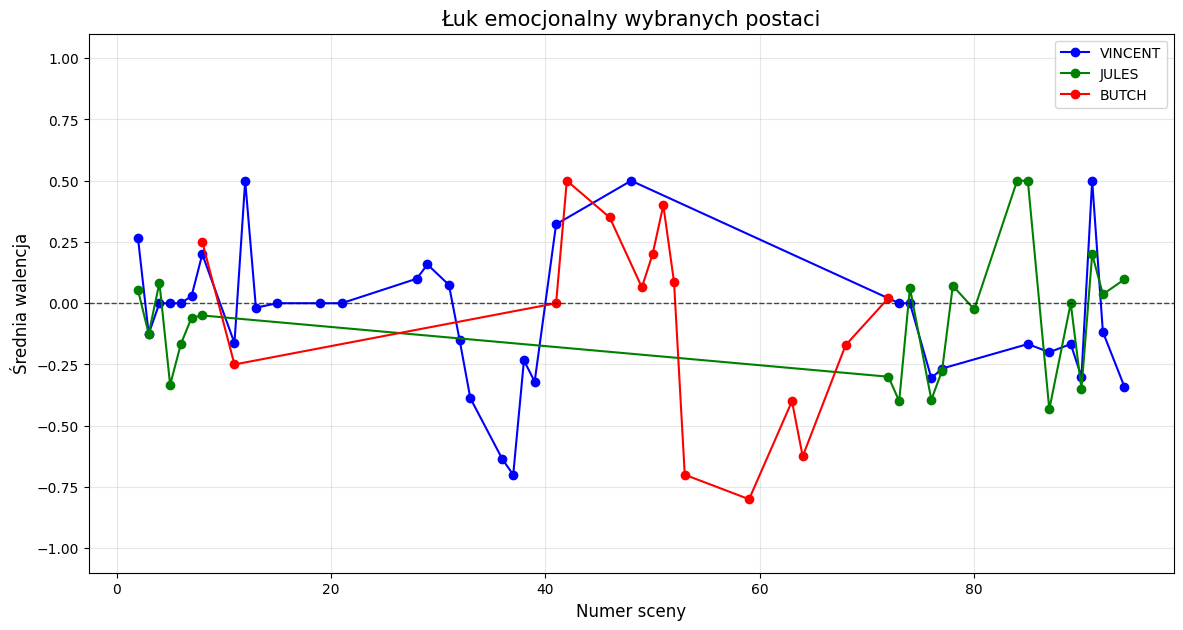

Statystyki wystąpień:
- VINCENT: występuje w 35 scenach
- JULES: występuje w 22 scenach
- BUTCH: występuje w 15 scenach


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

try:
    # 1. Define characters and filter
    selected_chars = ["VINCENT", "JULES", "BUTCH"]
    subset = emocje[emocje['postac'].isin(selected_chars)]

    # 2. Group by character and scene to get average valence
    char_arcs = subset.groupby(['postac', 'numer_sceny'])['walencja'].mean().reset_index()

    # 3. Plotting
    plt.figure(figsize=(14, 7))
    colors = {'VINCENT': 'blue', 'JULES': 'green', 'BUTCH': 'red'}

    for char in selected_chars:
        char_data = char_arcs[char_arcs['postac'] == char]

        # Check condition: count of scenes
        num_scenes = char_data['numer_sceny'].nunique()
        if num_scenes < 5:
            print(f"⚠️ OSTRZEŻENIE: Postać {char} występuje tylko w {num_scenes} scenach.")

        plt.plot(char_data['numer_sceny'], char_data['walencja'], marker='o', label=char, color=colors.get(char))

    # Horizontal reference line
    plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

    plt.title('Łuk emocjonalny wybranych postaci', fontsize=15)
    plt.xlabel('Numer sceny', fontsize=12)
    plt.ylabel('Średnia walencja', fontsize=12)
    plt.ylim(-1.1, 1.1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # 4. Display counts
    print("Statystyki wystąpień:")
    for char in selected_chars:
        n_scen = subset[subset['postac'] == char]['numer_sceny'].nunique()
        print(f"- {char}: występuje w {n_scen} scenach")

except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")
    print(f"Dostępne postacie w danych: {emocje['postac'].unique()[:10]}...")

#### Po uruchomieniu powinieneś zobaczyć

- Wykres z trzema liniami w różnych kolorach.
- Widoczne różnice w trajektoriach emocjonalnych między postaciami.

> **Pytanie interpretacyjne:** Czy „emocjonalne doliny" jednej postaci pokrywają się ze „szczytami" drugiej? Co to mówi o ich relacji w narracji?

---
## Etap 5/6 — Emocje według płci

Łączymy dwa wymiary: emocje i płeć. Pytamy, czy kobiety i mężczyźni w tym scenariuszu wyrażają inne emocje.

#### Twoja kolej: uzupełnij i uruchom

Przejrzyj dane w komórce podglądu powyżej. Wypełnij jedną lukę `[UZUPEŁNIJ: …]` w komórce kodu poniżej i uruchom.

In [24]:
# TWOJA KOLEJ: wypełnij lukę [UZUPEŁNIJ: …], potem uruchom tę komórkę.
moj_prompt = """
Kontekst:
Masz tabelę kwestii z kolumną emocja w zmiennej `emocje`. Masz tabelę postaci z kolumną płeć (K/M/?) w zmiennej `postacie`. Nazwy kolumn widoczne powyżej w komórce podglądu.

Wejście:
Tabele `emocje` i `postacie` z kolumnami widocznymi powyżej.

Zadanie:
(1) Połącz tabele po nazwie postaci, żeby każda kwestia miała przypisaną płeć. (2) Pomiń postacie o płci "?". (3) Policz, jaki procent kwestii z każdą emocją przypada na K i na M — normalizuj do 100% osobno dla każdej płci. (4) Narysuj grupowany wykres słupkowy: emocje na osi X, dwie grupy słupków (K i M) w różnych kolorach.

Pokaż wynik:
- grupowany wykres słupkowy z legendą K/M,
- wartości procentowe na słupkach,
- ostrzeżenie jeśli jedna z płci ma mniej niż 20 kwestii.

Warunek poprawności:
Procenty emocji dla K sumują się do 100%, tak samo dla M.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem dotyczy łączenia tabel albo brakujących wartości płci.

Nie rób jeszcze:
Nie zapisuj pliku.
"""
assert "[UZUPEŁNIJ" not in moj_prompt, \
    "⛔ Wypełnij lukę [UZUPEŁNIJ: …] — zdecyduj, co zrobić z wierszami o płci '?'."
assert len(moj_prompt.strip()) > 200, \
    "⛔ Prompt za krótki — wypełnij brakującą sekcję."
print("✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:\n")
print(moj_prompt)

✅ Prompt gotowy. Skopiuj poniższą treść do asystenta AI:


Kontekst:
Masz tabelę kwestii z kolumną emocja w zmiennej `emocje`. Masz tabelę postaci z kolumną płeć (K/M/?) w zmiennej `postacie`. Nazwy kolumn widoczne powyżej w komórce podglądu.

Wejście:
Tabele `emocje` i `postacie` z kolumnami widocznymi powyżej.

Zadanie:
(1) Połącz tabele po nazwie postaci, żeby każda kwestia miała przypisaną płeć. (2) Pomiń postacie o płci "?". (3) Policz, jaki procent kwestii z każdą emocją przypada na K i na M — normalizuj do 100% osobno dla każdej płci. (4) Narysuj grupowany wykres słupkowy: emocje na osi X, dwie grupy słupków (K i M) w różnych kolorach.

Pokaż wynik:
- grupowany wykres słupkowy z legendą K/M,
- wartości procentowe na słupkach,
- ostrzeżenie jeśli jedna z płci ma mniej niż 20 kwestii.

Warunek poprawności:
Procenty emocji dla K sumują się do 100%, tak samo dla M.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem dotyczy łączenia tabel albo brakujących wartości płci.

Nie rób jeszcze:
Nie

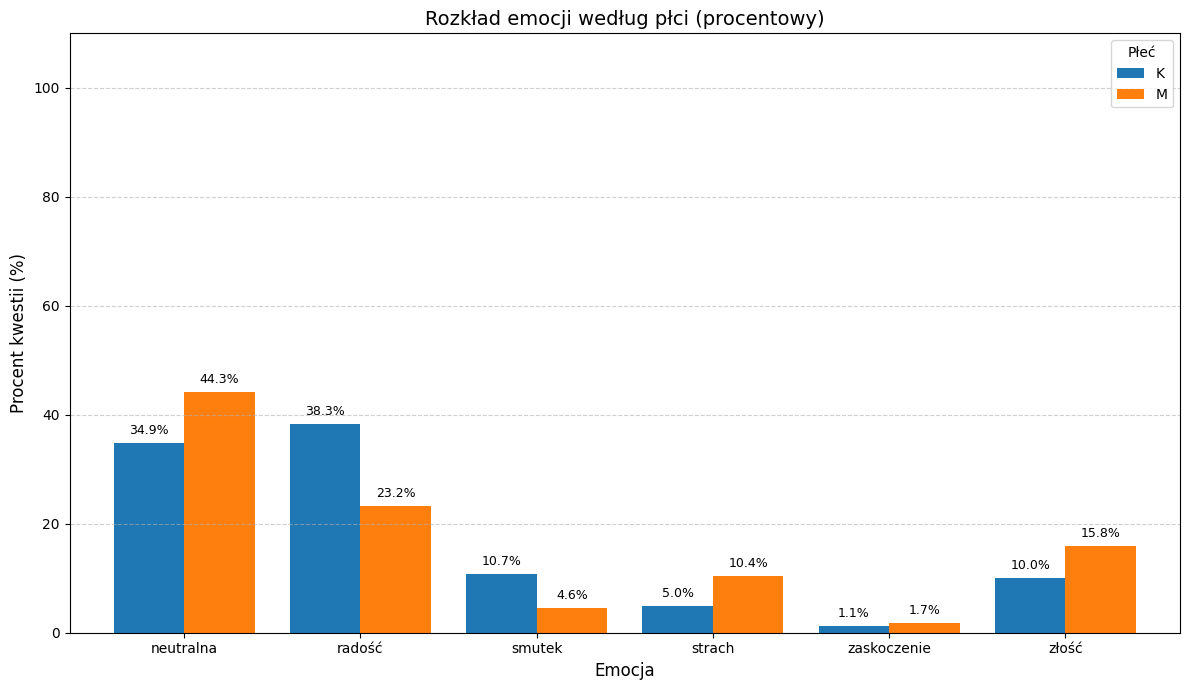

Statystyki:
- Płeć K: 261 kwestii
- Płeć M: 915 kwestii

Weryfikacja sum (powinno być 100.0):
plec
K    100.0
M    100.0
dtype: float64


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. Merge tables to assign gender
    merged_df = emocje.merge(postacie[['postac', 'plec']], on='postac', how='left')

    # 2. Filter out unknown gender '?'
    merged_df = merged_df[merged_df['plec'].isin(['K', 'M'])]

    # 3. Calculate percentages normalized per gender
    # Group by gender and emotion
    gender_emotions = merged_df.groupby(['plec', 'emocja'], observed=False).size().unstack(fill_value=0)

    # Normalize so each gender's total equals 100%
    gender_percentages = gender_emotions.div(gender_emotions.sum(axis=1), axis=0) * 100

    # 4. Plotting
    ax = gender_percentages.T.plot(kind='bar', figsize=(12, 7), width=0.8)

    plt.title('Rozkład emocji według płci (procentowy)', fontsize=14)
    plt.xlabel('Emocja', fontsize=12)
    plt.ylabel('Procent kwestii (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.ylim(0, 110)
    plt.legend(title='Płeć')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Add percentage values on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 9),
                        textcoords='offset points',
                        fontsize=9)

    plt.tight_layout()
    plt.show()

    # 5. Summary and warnings
    print("Statystyki:")
    for g in ['K', 'M']:
        count = len(merged_df[merged_df['plec'] == g])
        print(f"- Płeć {g}: {count} kwestii")
        if count < 20:
            print(f"⚠️ OSTRZEŻENIE: Płeć '{g}' ma bardzo małą liczbę kwestii ({count}).")

    # Verify sums
    print("\nWeryfikacja sum (powinno być 100.0):")
    print(gender_percentages.sum(axis=1))

except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")
    print("Podpowiedź: Sprawdź czy kolumny 'postac' w obu tabelach mają ten sam format danych.")

#### Po uruchomieniu powinieneś zobaczyć

- Wykres porównujący rozkład emocji między kobietami i mężczyznami.
- Wartości procentowe (umożliwiające porównanie mimo różnej liczby kwestii).
- Wyraźne etykiety płci i kategorii emocji.

#### Pytanie interpretacyjne

Czy rozkład emocji różni się między płciami? Które emocje są „sfeminizowane" lub „zmaskulinizowane" w tym konkretnym filmie? Jak ten wynik ma się do Twoich intuicji z oglądania?

> **Zastrzeżenie metodologiczne:** emocja przypisana przez model to interpretacja tekstu dialogu — nie subiektywne odczucie postaci ani intencja autorska. Wynik mówi coś o *reprezentacji*, nie o *rzeczywistości*.

---
## Etap 6/6 — Eksport danych

Zapisujemy wyniki oceny emocji do pliku wejściowego dla NB3.

In [26]:
# === ETAP 6/6 · EKSPORT ===
assert 'emocje' in dir(), "⛔ Najpierw uruchom Etap 3 — brak tabeli `emocje`."
print(f"📍 Etap 6/6 · Eksport. `emocje` ({len(emocje):,} wierszy) → pliki CSV.")

📍 Etap 6/6 · Eksport. `emocje` (1,193 wierszy) → pliki CSV.


### Krok 6A. Zapis pliku `emocje.csv`

#### Cel i sens analityczny

`emocje.csv` to „wzbogacona" wersja `dialogi.csv` — zawiera kwestie z ocenami emocji. `emocje_postaci.csv` to emocjonalne portrety postaci. W NB3 dołączymy te dane do sieci postaci.

#### Prompt dla modelu

```text
Kontekst:
Masz tabelę kwestii z ocenionymi emocjami i walencjami w zmiennej `emocje`.

Wejście:
Tabela `emocje` z kolumnami: numer sceny, postać, treść kwestii, liczba słów, walencja, emocja.

Zadanie:
Zapisz tę tabelę do pliku `emocje.csv` w kodowaniu UTF-8. Następnie wygeneruj skrócony plik `emocje_postaci.csv`, w którym każda postać ma jeden wiersz z kolumnami: postać, dominująca emocja (najczęstsza), średnia walencja, liczba kwestii. Pokaż jak pobrać oba pliki z Colab.

Pokaż wynik:
- komunikat o zapisaniu obu plików z liczbą wierszy,
- 5 pierwszych wierszy `emocje_postaci.csv`,
- wskazówkę jak pobrać pliki.

Warunek poprawności:
Oba pliki niepuste. Liczba wierszy w `emocje.csv` = liczba kwestii.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się zapisać i dlaczego.

Nie rób już nic więcej.
```

In [27]:
import pandas as pd
from google.colab import files

try:
    # 1. Zapisanie pełnej tabeli emocji
    emocje.to_csv('emocje.csv', index=False, encoding='utf-8')

    # 2. Tworzenie tabeli podsumowującej postacie
    # Obliczamy dominantę emocji, średnią walencję i liczbę kwestii
    emocje_postaci = emocje.groupby('postac').agg({
        'emocja': lambda x: x.mode()[0] if not x.mode().empty else 'neutralna',
        'walencja': 'mean',
        'tresc': 'count'
    }).reset_index()

    # Zmiana nazw kolumn
    emocje_postaci.columns = ['postac', 'dominująca_emocja', 'średnia_walencja', 'liczba_kwestii']

    # Zapisanie tabeli postaci
    emocje_postaci.to_csv('emocje_postaci.csv', index=False, encoding='utf-8')

    print(f"✅ Zapisano plik 'emocje.csv' ({len(emocje)} wierszy).")
    print(f"✅ Zapisano plik 'emocje_postaci.csv' ({len(emocje_postaci)} wierszy).")

    print("\n--- PODGLĄD EMOCJE_POSTACI.CSV (Top 5) ---")
    display(emocje_postaci.sort_values(by='liczba_kwestii', ascending=False).head(5))

    print("\n💡 Wskazówka: Aby pobrać pliki, kliknij ikonę folderu w lewym panelu Colab,")
    print("następnie kliknij trzy kropki przy pliku i wybierz 'Download'.")

except Exception as e:
    print(f"❌ Błąd podczas zapisu: {e}")

✅ Zapisano plik 'emocje.csv' (1193 wierszy).
✅ Zapisano plik 'emocje_postaci.csv' (55 wierszy).

--- PODGLĄD EMOCJE_POSTACI.CSV (Top 5) ---


,postac,dominująca_emocja,średnia_walencja,liczba_kwestii
46,VINCENT,neutralna,-0.056977,258
21,JULES,neutralna,-0.039234,209
7,BUTCH,radość,0.026667,135
14,FABIENNE,radość,0.056667,90
31,MIA,radość,0.272840,81



💡 Wskazówka: Aby pobrać pliki, kliknij ikonę folderu w lewym panelu Colab,
następnie kliknij trzy kropki przy pliku i wybierz 'Download'.


#### Po uruchomieniu powinieneś zobaczyć

- Potwierdzenie zapisania `emocje.csv` i `emocje_postaci.csv`.
- Podgląd emocjonalnych portretów postaci.
- Wskazówkę jak pobrać pliki z Colab.

---
## Co dalej?

- Masz teraz `emocje.csv` (kwestie z walencją i emocją) i `emocje_postaci.csv` (emocjonalne portrety postaci).
- W **NB3** połączysz te dane z siecią z modułu 1 i wygenerujesz prezentację HTML z czterema wykresami.
- Jeśli łuk emocjonalny jest zbyt płaski albo rozkład emocji zdegenerowany, wróć do Kroku 3A i zmodyfikuj wbudowaną instrukcję oceny emocji — iteracja jest częścią metody.